# Project covid MF order parameters and gisaid sequences on a 2D map




In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import Normalize
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.stats import pearsonr
from utils_mean_field import *
from script_mean_field_covid import *
# from utils_analysis_mf import *


main_path = "../"

sys.path.append(main_path + "PGM/source/")
sys.path.append(main_path + "PGM/utilities/")
import utilities, Proteins_utils, sequence_logo, plots_utils
sys.path.append(main_path + "covid/")
sys.path.append(main_path + "lattice/")
os.chdir(main_path + "covid/")

from global_variables import *
from utils_evaluate_seq import *
os.chdir('../mean_field_theory')



e:\ESCAPE_PATHS\covid\../PGM/source\numba_utilities.py:1124: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float32, 2, 'F', False, aligned=True), Array(float32, 2, 'A', False, aligned=True))
  dmean_v_dw = np.dot(s1.T, V)
e:\ESCAPE_PATHS\covid\../PGM/source\numba_utilities.py:961: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float32, 1, 'A', False, aligned=True), Array(float32, 2, 'A', False, aligned=True))
  mean_V = np.dot(weights, V) / sum_weights


Loaded 29 KD vectors


C:\Users\maria\AppData\Roaming\Python\Python312\site-packages\Bio\pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


# Read results

# PATH CONSTANTS

In [2]:
PROT_INIT = Proteins_utils.load_FASTA("../covid/exp_data/wt_omicron.fasta")[0]
BA1=Proteins_utils.load_FASTA("../covid/exp_data/wt_omicron.fasta")[1]
PROT_INIT = PROT_INIT[BEGIN:-END]
WT=PROT_INIT
BA1=BA1[BEGIN:-END]
L = PROT_INIT.shape[0]



In [3]:
ab_names = list(ESCAPE_VECTORS.keys())
L=178
wab = np.zeros((L, 20, len(ab_names)))
for idx, ab in enumerate(ab_names):
    w_ab = ESCAPE_VECTORS[ab].reshape(L, 20)  # "no bias"
    wab[:, :, idx] = w_ab
#put last dimension first
wab = np.moveaxis(wab, -1, 0)
print("wab shape", wab.shape)
wgamma_flat= wab.reshape(wab.shape[0], -1)

wgamma_flat.min()

wab shape (29, 178, 20)


-4.605170185988091

# Get order parameters

In [4]:
# folder = 'results_scripts/D_20_covid/mean_f_free_ab_beta_ab_1_D_20_beta_phi_1'
folder='results_scripts/covid_D_20/mean_f_free_ab_beta_ab_5_D_1'
mopt = np.load(f"{folder}/mopt.npy") [:,:29]
mopt.shape#(21, 29)



(21, 29)

In [5]:
def project_without_blas(one_hot_seqs, wgamma_flat):
    """
    Project each of N sequences (length-D) onto each of K axes,
    without calling the BLAS-backed dot() function.
    Returns an (N, K) array of projections.
    """
    N, D = one_hot_seqs.shape
    K, D2 = wgamma_flat.shape
    assert D == D2
    
    # pre-allocate output
    projections = np.empty((N, K), dtype=one_hot_seqs.dtype)
    
    # for each axis, multiply elementwise and sum
    for k in range(K):
        # Broadcast: (N, D) * (D,) → (N, D), then sum over D → (N,)
        projections[:, k] = (one_hot_seqs * wgamma_flat[k]).sum(axis=1)
    
    return projections


In [6]:
import numpy as np

# 1. Define the alphabet your model was trained on (Standard 20 Amino Acids)
AA_ALPHABET = "ACDEFGHIKLMNPQRSTVWY" 
aa_to_int = {aa: i for i, aa in enumerate(AA_ALPHABET)}

def one_hot_encode_concat(s):
    """
    One-hot encodes a sequence string into a flattened vector.
    """
    # Initialize matrix: Sequence Length x Alphabet Size
    one_hot_matrix = np.zeros((len(s), len(AA_ALPHABET)), dtype=int)
    
    for i, char in enumerate(s):
        # FIX: Use the dictionary to map 'char' (str) to 'idx' (int)
        if char in aa_to_int:
            idx = aa_to_int[char]
            one_hot_matrix[i, idx] = 1
        else:
            one_hot_matrix[i, char] = 1


    # Flatten to match the shape expected by project_without_blas

    return one_hot_matrix.flatten()



# Get MCMC paths

In [7]:
one_hot_encode_concat(WT).sum()

178

In [8]:
def get_mcmc_proba_aa(dir,wgamma_flat):
    paths_nb=100
    print("beta_w", beta_w)
    proj_mat=[]
    for path_no in range(paths_nb):
        fasta_file = os.path.join(dir, f"output_{path_no}.fasta")
        if not os.path.exists(fasta_file):
            print('not found')
            continue
        sequences = Proteins_utils.load_FASTA(fasta_file, drop_duplicates=False)
        one_hot_seqs = np.array([one_hot_encode_concat(seq) for seq in sequences])
        print
        projs= project_without_blas(one_hot_seqs, wgamma_flat)
        proj_mat.append(projs)
    proj_mat= np.array(proj_mat)
    return proj_mat
beta_w=5
dir_mcmc = f"../covid/paths/test_covid_T20_beta_ab_{beta_w}/"
paths_mcmc=get_mcmc_proba_aa(dir_mcmc, wgamma_flat)


beta_w 5


In [9]:
paths_mcmc.sum()

-156799

In [10]:
paths_mcmc.max()

0

# Evolution of ab resistance by step

In [11]:
paths_mcmc.shape

(100, 21, 29)

In [12]:
mean_paths=np.mean(paths_mcmc, axis=0)[:,:]
mean_paths.shape


(21, 29)

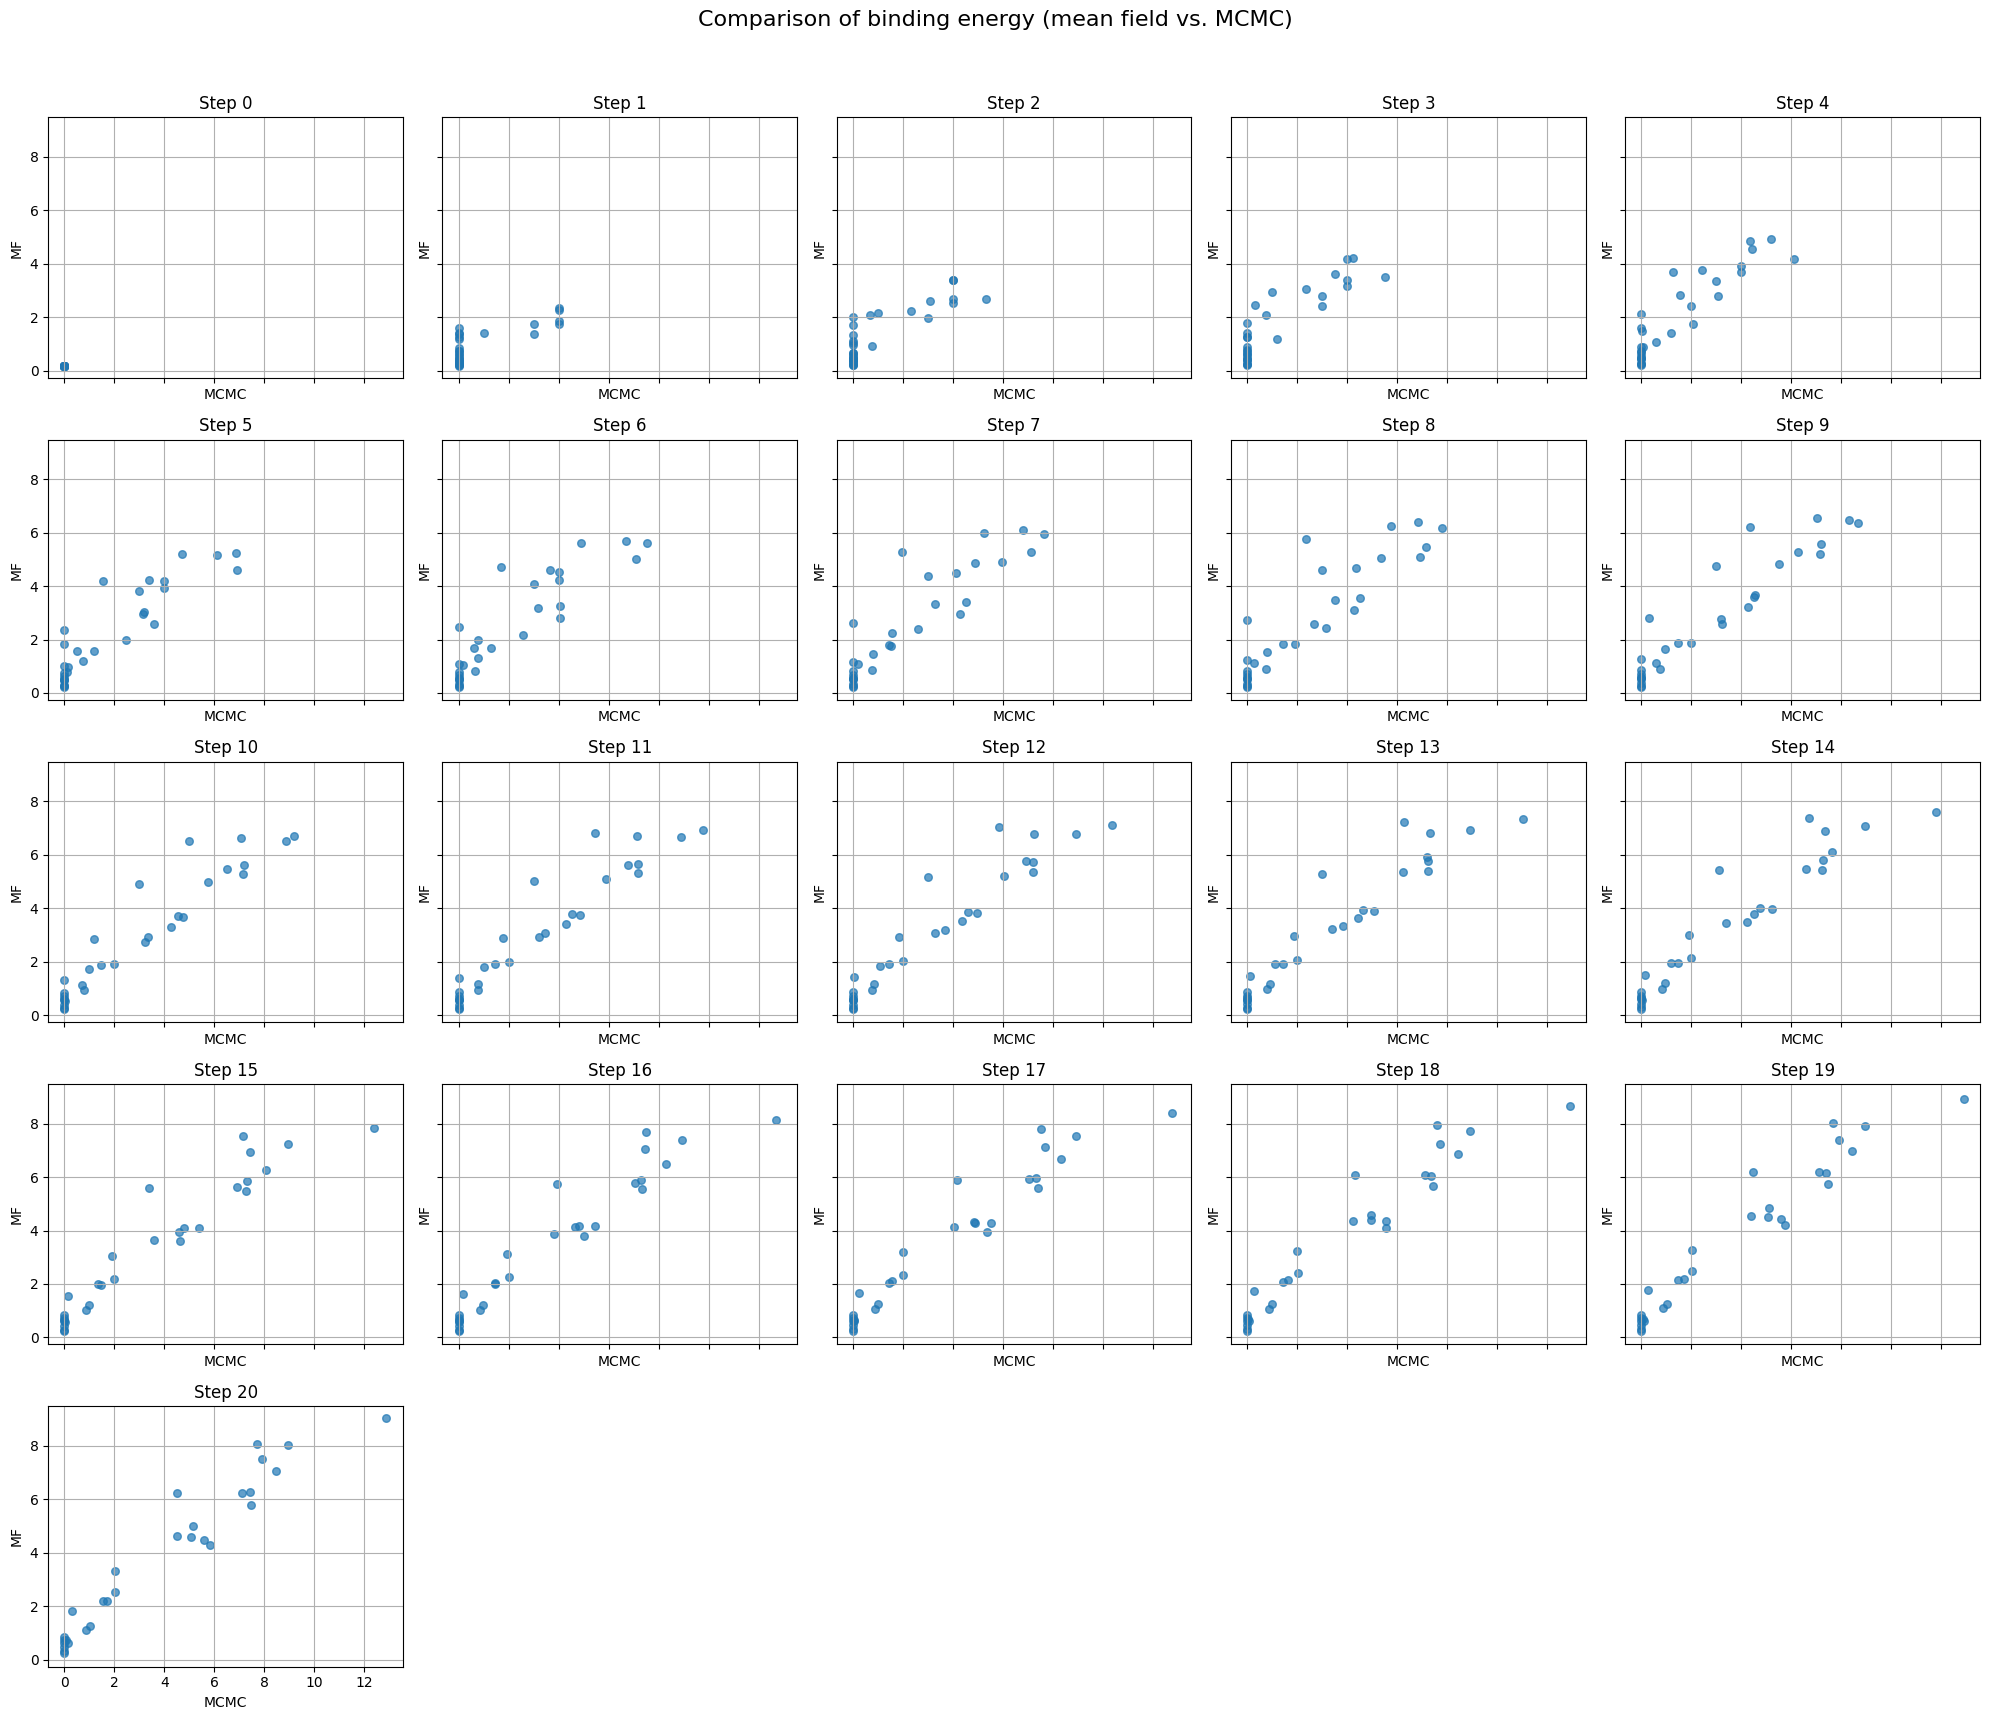

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Assume mean_paths and mopt exist and have shape (20, 29)
n_steps = mean_paths.shape[0]

# Plot config
ncols = 5
nrows = (n_steps + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows), sharex=True, sharey=True)
axes = axes.flatten()

for i in range(n_steps):
    ax = axes[i]
    ax.scatter(-mean_paths[i], -mopt[i], s=30, alpha=0.7)
    ax.set_title(f"Step {i}")
    ax.set_xlabel("MCMC")
    ax.set_ylabel("MF")
    ax.grid(True)

# Hide extra subplots
for j in range(n_steps, len(axes)):
    axes[j].axis('off')

# 1. Use fig.suptitle for the global title
fig.suptitle('Comparison of binding energy (mean field vs. MCMC)', fontsize=16)

# 2. Adjust rect to leave space at the top for the suptitle (default is top=1)
plt.tight_layout(rect=[0, 0, 1, 0.96]) 
plt.show()

In [ ]:
ab_class_df=pd.read_csv('../covid/exp_data/bloom_ab_classification/ab_classification.csv')
import matplotlib.pyplot as plt

# Map class information to each antibody in df
class_mapping = ab_class_df.set_index('condition')['condition_subtype'].to_dict()
class_mapping

{'COV2-2196': 'class 1',
 'COV2-2130': 'class 3',
 'COV2-2955': 'class 2',
 'CR3022': 'class 4',
 'COV2-2677': 'class 4',
 'COV2-2082': 'class 4',
 'COV2-2094': 'class 4',
 'COV2-2165': 'class 1',
 'COV2-2832': 'class 1',
 'COV2-2479': 'class 2',
 'COV2-2050': 'class 2',
 'COV2-2096': 'class 2',
 'COV2-2499': 'class 3',
 'C002': 'class 2',
 'C105': 'class 1',
 'C110': 'class 3',
 'C121': 'class 2',
 'C135': 'class 3',
 'C144': 'class 2',
 'LY-CoV555': 'class 2',
 'REGN10933': 'class 1',
 'REGN10987': 'class 3',
 'LY-CoV016': 'class 1',
 'S309': 'class 3',
 'S2H97': 'class 4',
 'S304': 'class 4',
 'S2X35': 'class 4',
 'S2E12': 'class 1',
 'S2X16': 'class 2',
 'S2H58': 'class 2',
 'S2H13': 'class 2',
 'S2D106': 'class 2',
 'S2X58': 'class 2',
 'S2H14': 'class 1',
 'S2X227': 'class 3',
 'S2X259': 'class 4'}

In [ ]:


# Convert ab_names to classes
ab_classes = [class_mapping.get(ab, 'Unknown') for ab in ab_names]

# Define class colors
unique_classes = sorted(set(ab_classes))
palette = plt.get_cmap("tab10")
class_to_color = {cls: palette(i) for i, cls in enumerate(unique_classes)}
colors = [class_to_color[c] for c in ab_classes]

# Steps to plot


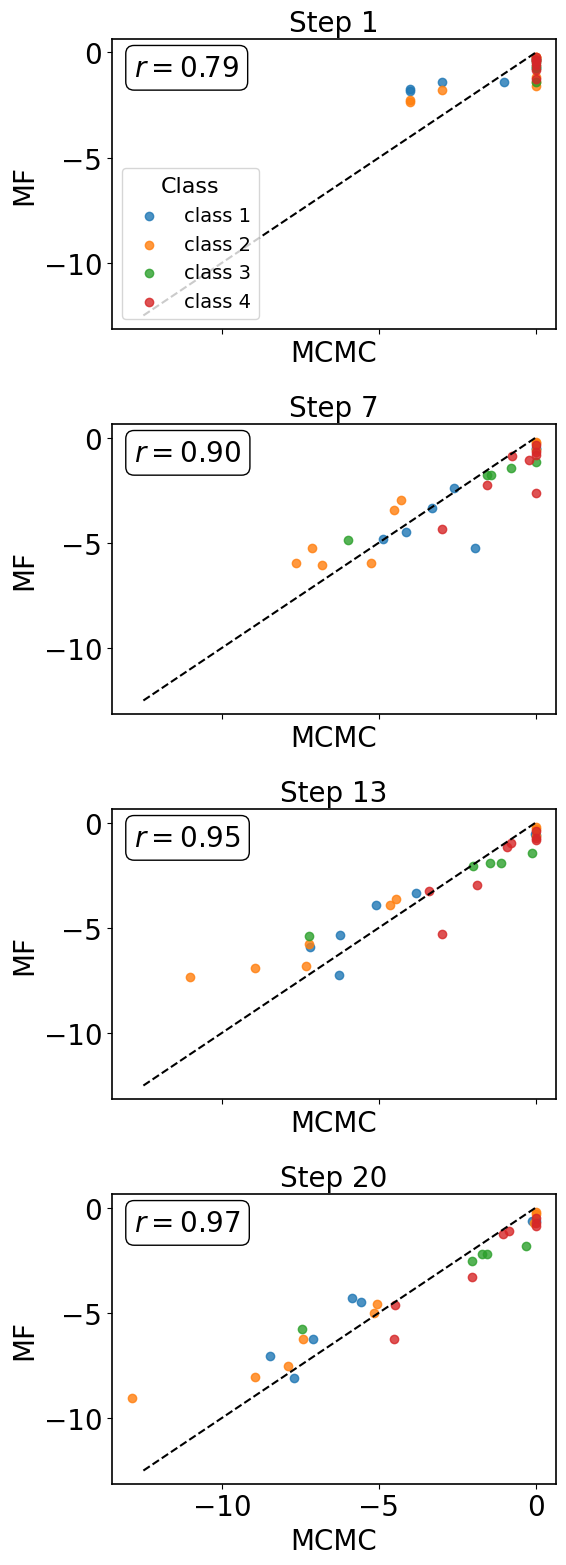

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

steps_to_plot = [1, 7, 13, 20]

# Set up plot with larger fonts
plt.rcParams.update({
    'font.size': 18,
    'axes.titlesize': 20,
    'axes.labelsize': 18,
    'legend.fontsize': 16,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16
})

n_steps = len(steps_to_plot)
ncols = 1
nrows = n_steps  # one plot per row

fig, axes = plt.subplots(nrows, ncols, figsize=(6, 4 * nrows), sharex=True, sharey=True)

# If only one axis, wrap in list to make iterable
if n_steps == 1:
    axes = [axes]

for i, step in enumerate(steps_to_plot):
    ax = axes[i]
    x = mean_paths[step]
    y = mopt[step]
    
    for cls in unique_classes:
        idx = [j for j, c in enumerate(ab_classes) if c == cls]
        ax.scatter(np.array(x)[idx], np.array(y)[idx], label=cls, color=class_to_color[cls], alpha=0.8)
    
    # Pearson correlation
    r, _ = pearsonr(x, y)
    ax.text(
        0.05, 0.95, f"$r = {r:.2f}$", transform=ax.transAxes,
        verticalalignment='top', horizontalalignment='left',
        bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'),
        fontsize=20
    )

    ax.set_title(f"Step {step}", fontsize=20)
    ax.set_xlabel("MCMC", fontsize=20)
    ax.set_ylabel("MF", fontsize=20)

    ax.tick_params(axis='x', labelsize=20)
    ax.tick_params(axis='y', labelsize=20)
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.2)
    ax.plot([-12.5, 0], [-12.5, 0], linestyle='--', color='black')

# Legend inside the first subplot
axes[0].legend(
    title='Class',
    loc='lower left',
    fontsize=14,
    title_fontsize=16,
    frameon=True
)

plt.tight_layout()
plt.show()


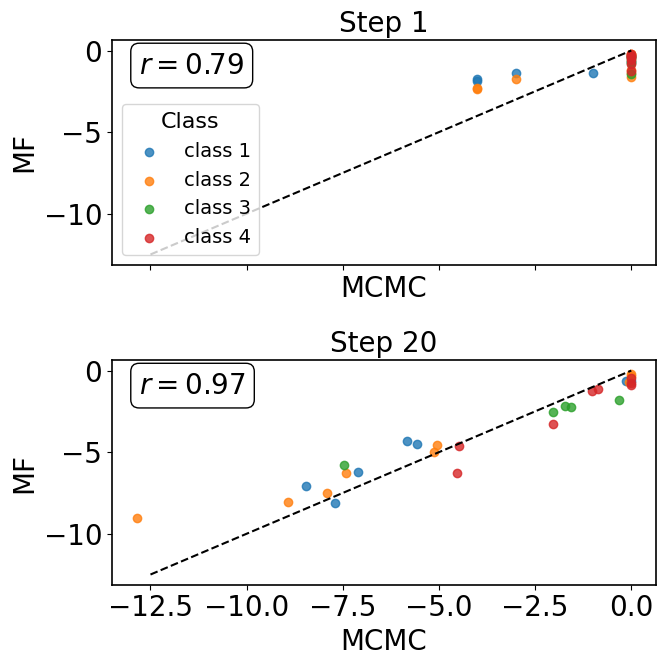

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

steps_to_plot = [1, 20]

# Set up plot with larger fonts
plt.rcParams.update({
    'font.size': 18,
    'axes.titlesize': 20,
    'axes.labelsize': 18,
    'legend.fontsize': 16,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16
})

n_steps = len(steps_to_plot)
ncols = 1
nrows = n_steps  # one plot per row

fig, axes = plt.subplots(nrows, ncols, figsize=(7, 3.5 * nrows), sharex=True, sharey=True)

# If only one axis, wrap in list to make iterable
if n_steps == 1:
    axes = [axes]

for i, step in enumerate(steps_to_plot):
    ax = axes[i]
    x = mean_paths[step]
    y = mopt[step]
    
    for cls in unique_classes:
        idx = [j for j, c in enumerate(ab_classes) if c == cls]
        ax.scatter(np.array(x)[idx], np.array(y)[idx], label=cls, color=class_to_color[cls], alpha=0.8)
    
    # Pearson correlation
    r, _ = pearsonr(x, y)
    ax.text(
        0.05, 0.95, f"$r = {r:.2f}$", transform=ax.transAxes,
        verticalalignment='top', horizontalalignment='left',
        bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'),
        fontsize=20
    )

    ax.set_title(f"Step {step}", fontsize=20)
    ax.set_xlabel("MCMC", fontsize=20)
    ax.set_ylabel("MF", fontsize=20)

    ax.tick_params(axis='x', labelsize=20)
    ax.tick_params(axis='y', labelsize=20)
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.2)
    ax.plot([-12.5, 0], [-12.5, 0], linestyle='--', color='black')

# Legend inside the first subplot
axes[0].legend(
    title='Class',
    loc='lower left',
    fontsize=14,
    title_fontsize=16,
    frameon=True
)

plt.tight_layout()
plt.show()
